Rubtcova Vera  
Algorithms Task 3

## Goal  
The use of first- and second-order methods (Gradient Descent, Non-linear
Conjugate Gradient Descent, Newton’s method and Levenberg-Marquardt
algorithm) in the tasks of unconstrained nonlinear optimization

In [1]:
import math
import pandas as pd
import random
import matplotlib.pyplot as plt

#### Task
Generate random numbers 𝛼 ∈ (0,1) and 𝛽 ∈ (0,1)Furthermore, generate the noisy data {𝑥 ,𝑦}, where 𝑘 = 0,…,100, according to the following rule:   
𝑦ₖ = 𝛼𝑥ₖ + 𝛽 + 𝛿ₖ , 𝑥ₖ = k/100  
where 𝛿~𝑁(0,1) are values of a random variable with standard normal distribution. Approximate the data by the following linear and rational functions:   
 𝐹(𝑥,𝑎,𝑏) = 𝑎𝑥 +𝑏 (linear approximant),   
 𝐹(𝑥,𝑎,𝑏) = 𝑎 / (1 + 𝑏𝑥) (rational approximant),   
by means of least squares through the numerical minimization (with precision 𝜀 =
0.001) of the following function:   
D(𝑎, 𝑏) = ∑ (𝐹(𝑥ₖ, 𝑎, 𝑏) − 𝑦ₖ)²  

To solve the minimization problem, use the methods of Gradient Descent, Conjugate
Gradient Descent, Newton’s method and Levenberg-Marquardt algorithm. If
necessary, set the initial approximations and other parameters of the methods.
Visualize the data and the approximants obtained in a plot separately for each type
of approximant so that one can compare the results for the numerical methods used.
Analyze the results obtained (in terms of number of iterations, precision, number of
function evaluations, etc.) and compare them with those from Task 2 for the same
dataset.


In [2]:
eps = 0.001

In [3]:
def generate_data():
  alpha = random.uniform(0,1)
  beta = random.uniform(0,1)

  xs = []
  ys = []
  for k in range(101):
    x_k = k / 100
    delta_k = random.gauss(0,1)
    y_k = alpha * x_k + beta + delta_k
    xs.append(x_k)
    ys.append(y_k)

  return alpha, beta, xs, ys

In [4]:
random.seed(200)
alpha, beta, xs, ys = generate_data()
print(f"True alpha = {alpha:.4f},\nTrue beta = {beta:.4f}")

True alpha = 0.0456,
True beta = 0.2034


In [5]:
def D(F, a, b, xs, ys):
  d = 0
  for k in range(101):
    d += (F(xs[k], a, b) - ys[k])**2
  return d

In [6]:
def linear_approximant(x, a, b):
  return a * x + b

def rational_approximant(x, a, b):
  return a / (1 + b * x)

In [7]:
def golden_section(f, a, b, eps):
  calcs_cnt = 0
  iterations = 0

  x1 = a + (3 - math.sqrt(5)) / 2 * (b - a)
  x2 = a + (math.sqrt(5) - 1) / 2 * (b - a)

  f_x1 = f(x1)
  f_x2 = f(x2)
  calcs_cnt += 2

  while b - a >= eps:
    if f_x1 <= f_x2:
      b = x2
      x2 = x1
      f_x2 = f_x1
      x1 = a + (3 - math.sqrt(5)) / 2 * (b - a)
      f_x1 = f(x1)
    else:
      a = x1
      x1 = x2
      f_x1 = f_x2
      x2 = a + (math.sqrt(5) - 1) / 2 * (b - a)
      f_x2 = f(x2)

    calcs_cnt +=1
    iterations +=1

  best_x = (a + b) / 2
  best_f = f(best_x)
  calcs_cnt += 1
  return best_f, best_x, calcs_cnt, iterations

#### Theory: Gradient Descent - Algorithm
1. Choose a starting point $(a_0, b_0)$ and a step size (learning rate) $\beta$.  
2. At each iteration, compute the gradient  
 $\nabla D(a_n,b_n) = \left(\frac{\partial D}{\partial a}, \frac{\partial D}{\partial b}\right)$   
 at the current point.  

3. Move against the gradient:  
 $(a_{n+1}, b_{n+1}) = (a_n, b_n) - \beta\cdot\nabla D(a_n,b_n)$.   
 4. Stop when   
 $\|(a_{n+1},b_{n+1}) - (a_n,b_n)\| \le \varepsilon$.

For the linear model $F(x,a,b)=ax+b$, the partial derivatives are derived via the chain rule from   
$D(a,b)=\sum(ax_k+b-y_k)^2$:  
$$\frac{\partial D}{\partial a} = \sum 2(ax_k+b-y_k)x_k,   
\qquad \frac{\partial D}{\partial b} = \sum 2(ax_k+b-y_k)$$

For the rational model   
$F(x,a,b)=\frac{a}{1+bx}$, with $u_k=1+bx_k$:   
$$\frac{\partial D}{\partial a} = \sum 2\left(\frac{a}{u_k}-y_k\right)\cdot\frac{1}{u_k},  
 \qquad \frac{\partial D}{\partial b} = \sum 2\left(\frac{a}{u_k}-y_k\right)\cdot\left(-\frac{ax_k}{u_k^2}\right)$$

In [8]:
def line_gradient(a, b, xs, ys):
  a_sum = 0
  b_sum = 0
  for i in range(101):
    a_sum += 2 * (a * xs[i] + b - ys[i]) * xs[i]
    b_sum += 2 * (a * xs[i] + b - ys[i])
  return a_sum, b_sum

In [9]:
def rational_gradient(a, b, xs, ys):
  a_sum = 0
  b_sum = 0
  for i in range(101):
    a_sum += ((2 * a - 2*ys[i]*(1+b*xs[i]))) / ((1 + b*xs[i])**2)
    b_sum += ((2 * a - 2*ys[i]*(1+b*xs[i])) * -(a * xs[i])) / ((1 + b*xs[i])**3)

  return a_sum, b_sum

In [10]:
def gradient_descent(a, b, xs, ys, eps, lr, F):
  iterations = 0
  calcs_cnt = 0
  while True:
    a_sum, b_sum = F(a,b,xs,ys)
    an = a - lr * a_sum
    bn = b - lr * b_sum
    step = math.sqrt((an - a)**2 + (bn - b)**2)
    iterations += 1
    calcs_cnt += 101
    if step <= eps:
      return an,bn,iterations,calcs_cnt

    a = an
    b = bn

In [11]:
a_gd, b_gd, iterations_gd, calcs_cnt_dg = gradient_descent(0.5,0.5,xs,ys,eps,0.001, line_gradient)

In [12]:
a_gdr, b_gdr, iterations_gdr, calcs_cnt_gbr = gradient_descent(0.5,0.5,xs,ys,eps,0.001, rational_gradient)

In [13]:
print(f"Gradient Descent (Linear): a = {a_gd:.4f}, b = {b_gd:.4f}, D = {D(linear_approximant, a_gd, b_gd, xs, ys):.4f}, calcs = {calcs_cnt_dg}, iterations = {iterations_gd}")
print(f"Gradient Descent (Rational): a = {a_gdr:.4f}, b = {b_gdr:.4f}, D = {D(rational_approximant, a_gdr, b_gdr, xs, ys):.4f}, calcs = {calcs_cnt_gbr}, iterations = {iterations_gdr}")

Gradient Descent (Linear): a = -0.1137, b = 0.3825, D = 98.1374, calcs = 15150, iterations = 150
Gradient Descent (Rational): a = 0.4133, b = 0.5147, D = 98.1461, calcs = 1919, iterations = 19


#### Theory: Conjugate Gradient Descent — Algorithm

1. Start at $(a_0,b_0)$; compute the anti-gradient $\Delta a_0 = -\nabla D(a_0,b_0)$ and set the initial direction $s_0=\Delta a_0$.  
2. Find the step size $\alpha_n$ that minimizes $D$ along the direction $s_n$ (one-dimensional line search, via golden section).  
3. Move to the new point: $(a_{n+1},b_{n+1}) = (a_n,b_n)+\alpha_n s_n$.  
4. Compute the new anti-gradient $\Delta a_{n+1}$ and the coefficient $\beta_{n+1}$ (Fletcher-Reeves formula):    

$$\beta_{n+1} = \frac{\Delta a_{n+1}^T\Delta a_{n+1}}{\Delta a_n^T\Delta a_n}$$  
5. Build the new direction: $s_{n+1} = \Delta a_{n+1} + \beta_{n+1}s_n$.  
6. Repeat until $\|(a_{n+1},b_{n+1})-(a_n,b_n)\|\le\varepsilon$.   

This method converges considerably faster than plain gradient descent because it avoids the zig-zagging behavior typical of steepest descent in narrow (ravine-shaped) valleys of $D(a,b)$.

In [14]:
def conjugate_gradient(a, b, xs, ys, eps, F, appr,right, eps_golden):
  iterations = 0
  calcs_cnt = 0
  da, db = F(a, b, xs, ys)
  sa, sb = -da, -db
  while True:
    g = lambda alpha: D(appr, a + alpha*sa, b + alpha*sb, xs, ys)
    best_f, best_alpha, calcs, iters = golden_section(g, 0, right, eps_golden)
    an = a + best_alpha * sa
    bn = b + best_alpha * sb
    step = math.sqrt((an - a)**2 + (bn - b)**2)
    iterations += 1
    calcs_cnt += 101
    if step <= eps:
      return an,bn,iterations,calcs_cnt

    try:
      da_new, db_new = F(an, bn, xs, ys)
    except (OverflowError, ZeroDivisionError):
      return an, bn, iterations, calcs_cnt
    beta = (da_new**2 + db_new**2) / (da**2 + db**2)
    sa, sb = (-da_new) + beta*sa, (-db_new) + beta*sb
    a, b = an, bn
    da, db = da_new, db_new

In [15]:
a_cg, b_cg, iterations_cg, calcs_cnt_cg = conjugate_gradient(0.5,0.5,xs,ys,eps, line_gradient, linear_approximant, 1, 0.0001)

In [16]:
a_cgr, b_cgr, iterations_cgr, calcs_cnt_cgr = conjugate_gradient(0.5,0.5,xs,ys,eps, rational_gradient, rational_approximant, 1, 0.0001)

In [17]:
print(f"Conjugate Gradient (Linear): a = {a_cg:.4f}, b = {b_cg:.4f}, D = {D(linear_approximant, a_cg, b_cg, xs, ys):.4f}, calcs = {calcs_cnt_cg}, iterations = {iterations_cg}")
print(f"Conjugate Gradient (Rational): a = {a_cgr:.4f}, b = {b_cgr:.4f}, D = {D(rational_approximant, a_cgr, b_cgr, xs, ys):.4f}, calcs = {calcs_cnt_cgr}, iterations = {iterations_cgr}")

Conjugate Gradient (Linear): a = -0.1783, b = 0.4172, D = 98.1022, calcs = 404, iterations = 4
Conjugate Gradient (Rational): a = 0.4176, b = 0.5901, D = 98.1413, calcs = 404, iterations = 4


#### Theory: Newton's Method — Algorithm
1. Start at $(a_0,b_0)$.  
2. At each iteration compute the gradient $\nabla D(a_n,b_n)$ and the Hessian matrix $Hf(a_n,b_n)$ (second partial derivatives).  
3. Update: $(a_{n+1},b_{n+1}) = (a_n,b_n) - [Hf(a_n,b_n)]^{-1}\nabla D(a_n,b_n)$.  
4. Stop when $\|(a_{n+1},b_{n+1})-(a_n,b_n)\|\le\varepsilon$.  
For the linear model, the Hessian is constant (does not depend on $a,b$), since $D$ is a quadratic function:  
$$H=\begin{pmatrix}\sum 2x_k^2 & \sum 2x_k\\ \sum 2x_k & 202\end{pmatrix}$$  
As a result, Newton's method converges to the exact minimum in just 2 iterations for the linear model.  
For the rational model the Hessian depends on $(a,b)$ and must be recomputed at every iteration:  
$$h_{aa}=\sum\frac{2}{u_k^2},\quad h_{ab}=h_{ba}=\sum\left(-\frac{4ax_k}{u_k^3}+\frac{2y_kx_k}{u_k^2}\right),\quad h_{bb}=\sum\left(\frac{4a^2x_k^2}{u_k^3}-\frac{2ay_kx_k^2}{u_k^2}\right)$$

In [18]:
def linear_gessian(xs, ys, a, b):
  h_aa, h_ab, h_ba, h_bb = 0, 0, 0, 0
  for i in range(101):
    h_aa += 2*(xs[i])**2
    h_ab += 2*(xs[i])
    h_ba += 2*(xs[i])
    h_bb += 2
  return h_aa, h_ab, h_ba, h_bb

In [19]:
def rational_gessian(xs, ys, a, b):
  h_aa, h_ab, h_ba, h_bb = 0, 0, 0, 0
  for i in range(101):
    u = 1 + b * xs[i]
    h_aa += 2/u**2
    h_ab += (-4*a*xs[i]) / u**3 + (2*ys[i]*xs[i]) / u**2
    h_bb += (4*(a**2) *(xs[i]**2)) / u**3 - (2* a * ys[i] *(xs[i]**2)) / u**2
    h_ba += (-4*a*xs[i]) / u**3 + (2*ys[i]*xs[i]) / u**2
  return h_aa, h_ab, h_ba, h_bb

In [20]:
def newton_method(a, b, xs, ys, eps, F, ges):
  iterations = 0
  calcs_cnt = 0

  while True:
    h_aa, h_ab, h_ba, h_bb = ges(xs, ys, a, b)
    det_hessian = 1 / ((h_aa*h_bb)-(h_ab*h_ba))
    anti_h_aa, anti_h_ab, anti_h_ba, anti_h_bb = det_hessian * h_bb, det_hessian * (-h_ab), det_hessian * (-h_ba), det_hessian * h_aa
    da, db = F(a, b, xs, ys)
    an, bn = a - (anti_h_aa*da + anti_h_ab*db), b - (anti_h_ba*da + anti_h_bb*db)
    step = math.sqrt((an - a)**2 + (bn - b)**2)
    iterations += 1
    calcs_cnt += 101
    if step <= eps:
      return an,bn,iterations,calcs_cnt
    a = an
    b = bn

In [21]:
a_nm, b_nm, iterations_nm, calcs_cnt_nm = newton_method(0.5,0.5,xs,ys,eps, line_gradient, linear_gessian)

In [22]:
a_nmr, b_nmr, iterations_nmr, calcs_cnt_nmr = newton_method(0.5,0.5,xs,ys,eps, rational_gradient, rational_gessian)

In [23]:
print(f"Newton Method (Linear): a = {a_nm:.4f}, b = {b_nm:.4f}, D = {D(linear_approximant , a_nm, b_nm, xs, ys):.4f}, calcs = {calcs_cnt_nm}, iterations = {iterations_nm}")
print(f"Newton Method (Rational): a = {a_nmr:.4f}, b = {b_nmr:.4f}, D = {D(rational_approximant , a_nmr, b_nmr, xs, ys):.4f}, calcs = {calcs_cnt_nmr}, iterations = {iterations_nmr}")

Newton Method (Linear): a = -0.1773, b = 0.4166, D = 98.1022, calcs = 202, iterations = 2
Newton Method (Rational): a = 0.4176, b = 0.5895, D = 98.1413, calcs = 1010, iterations = 10


#### Theory: Levenberg-Marquardt Algorithm — Algorithm
1. Start at $(a_0,b_0)$ with a damping parameter $\lambda$ (e.g. $\lambda=0.001$).  
2. Compute the residuals $r_k=F(x_k,a,b)-y_k$ and the Jacobian $J$, where $J_{k,1}=\frac{\partial r_k}{\partial a}$, $J_{k,2}=\frac{\partial r_k}{\partial b}$.  
3. Solve the damped normal equations for the update $\Delta\beta=(\Delta a,\Delta b)$:  
$$(J^TJ+\lambda I)\,\Delta\beta = J^T[y-f(\beta)]$$  
4. Evaluate $D$ at the trial point $(a+\Delta a, b+\Delta b)$:  
- if it decreased, accept the step and decrease $\lambda$ (e.g. $\lambda\mathrel{/}=10$);  
- otherwise, reject the step (keep the old point) and increase $\lambda$ (e.g. $\lambda\mathrel{*}=10$).  
5. Repeat until an accepted step satisfies $\|\Delta\beta\|\le\varepsilon$.  

$J^TJ$ is an approximation of the Hessian using only first-order information; for the linear model it is exact (equal to half the true Hessian), which is why LMA converges in a single iteration there. The parameter $\lambda$ makes the method interpolate between Gauss-Newton (small $\lambda$, fast near the minimum) and gradient descent (large $\lambda$, safer far from the minimum).

In [24]:
def linear_residuals(a, b, xs, ys):
  lambdas = []
  for i in range(101):
    lambdas.append(a * xs[i] + b - ys[i])
  return lambdas

In [25]:
def rational_residuals(a, b, xs, ys):
  lambdas = []
  for i in range(101):
    lambdas.append(a / (1 + b * xs[i]) - ys[i])
  return lambdas

In [26]:
def linear_yakob(a, b, xs, ys):
  jtj_aa = jtj_ab = jtj_ba = jtj_bb = jtr_a = jtr_b = 0
  r = linear_residuals(a, b, xs, ys)
  for i in range(101):
    jtj_aa += xs[i]**2
    jtj_ab += xs[i]
    jtj_ba += xs[i]
    jtj_bb += 1
    jtr_a += r[i] * xs[i]
    jtr_b += r[i]
  return jtj_aa, jtj_ab, jtj_ba, jtj_bb, jtr_a, jtr_b

In [27]:
def rational_yakob(a, b, xs, ys):
  jtj_aa = jtj_ab = jtj_ba = jtj_bb = jtr_a = jtr_b = 0
  r = rational_residuals(a, b, xs, ys)
  for i in range(101):
    j1 = 1 / (1 + b * xs[i])
    j2 = - (a * xs[i]) / (1 + b * xs[i])**2
    jtj_aa += j1 * j1
    jtj_ab += j1 * j2
    jtj_ba += j1 * j2
    jtj_bb += j2 * j2
    jtr_a += j1 * r[i]
    jtr_b += j2 * r[i]
  return jtj_aa, jtj_ab, jtj_ba, jtj_bb, jtr_a, jtr_b

In [28]:
def levenberg_marquardt(a, b, xs, ys, eps, apr, yakob, lambda_= 0.001):
  iterations = 0
  calcs_cnt = 0
  while True:
    jtj_aa, jtj_ab, jtj_ba, jtj_bb, jtr_a, jtr_b = yakob(a, b, xs, ys)
    jtj_aa = jtj_aa + lambda_
    jtj_bb = jtj_bb + lambda_
    det_yakobi = 1 / ((jtj_aa*jtj_bb)-(jtj_ab*jtj_ba))
    anti_jtj_aa, anti_jtj_ab, anti_jtj_ba, anti_jtj_bb = det_yakobi * jtj_bb, det_yakobi * (-jtj_ab), det_yakobi * (-jtj_ba), det_yakobi * jtj_aa
    delta_a = anti_jtj_aa*(-jtr_a) + anti_jtj_ab*(-jtr_b)
    delta_b = anti_jtj_ba*(-jtr_a) + anti_jtj_bb*(-jtr_b)
    a_try = a + delta_a
    b_try = b + delta_b

    if D(apr, a_try, b_try, xs, ys) < D(apr, a, b, xs, ys):
      an, bn = a_try, b_try
      lambda_ /= 10
      step = math.sqrt((an - a)**2 + (bn - b)**2)
      if step <= eps:
        return an,bn,iterations,calcs_cnt
      a, b = an, bn
    else:
      lambda_ *= 10

    iterations += 1
    calcs_cnt += 101

In [29]:
a_lm, b_lm, iterations_lm, calcs_cnt_lm = levenberg_marquardt(0.5,0.5,xs,ys,eps, linear_approximant, linear_yakob)
print(a_lm, b_lm, iterations_lm, calcs_cnt_lm, D(linear_approximant , a_lm, b_lm, xs, ys))

-0.17728149803703355 0.4165505445945515 1 101 98.102165070888


In [30]:
a_lmr, b_lmr, iterations_lmr, calcs_cnt_lmr = levenberg_marquardt(0.5,0.5,xs,ys,eps, rational_approximant, rational_yakob)
print(a_lmr, b_lmr, iterations_lmr, calcs_cnt_lmr, D(rational_approximant , a_lmr, b_lmr, xs, ys))

0.41773469622625464 0.5908942057098588 3 303 98.14131777054558


In [31]:
print(f"Levenberg Marquardt (Linear): a = {a_lm:.4f}, b = {b_lm:.4f}, D = {D(linear_approximant , a_lm, b_lm, xs, ys):.4f}, calcs = {calcs_cnt_lm}, iterations = {iterations_lm}")
print(f"Levenberg Marquardt (Rational): a = {a_lmr:.4f}, b = {b_lmr:.4f}, D = {D(rational_approximant , a_lmr, b_lmr, xs, ys):.4f}, calcs = {calcs_cnt_lmr}, iterations = {iterations_lmr}")

Levenberg Marquardt (Linear): a = -0.1773, b = 0.4166, D = 98.1022, calcs = 101, iterations = 1
Levenberg Marquardt (Rational): a = 0.4177, b = 0.5909, D = 98.1413, calcs = 303, iterations = 3


# Conclusion

In [32]:
results3 = pd.DataFrame([
    {"Function": "Linear",   "Method": "Gradient Descent",   "a": a_gd,   "b": b_gd,   "D(a,b)": D(linear_approximant, a_gd, b_gd, xs, ys),     "f-calculations": calcs_cnt_dg,  "Iterations": iterations_gd},
    {"Function": "Linear",   "Method": "Conjugate Gradient", "a": a_cg,   "b": b_cg,   "D(a,b)": D(linear_approximant, a_cg, b_cg, xs, ys),     "f-calculations": calcs_cnt_cg,  "Iterations": iterations_cg},
    {"Function": "Linear",   "Method": "Newton",             "a": a_nm,   "b": b_nm,   "D(a,b)": D(linear_approximant, a_nm, b_nm, xs, ys),     "f-calculations": calcs_cnt_nm,  "Iterations": iterations_nm},
    {"Function": "Linear",   "Method": "Levenberg-Marquardt","a": a_lm,   "b": b_lm,   "D(a,b)": D(linear_approximant, a_lm, b_lm, xs, ys),     "f-calculations": calcs_cnt_lm,  "Iterations": iterations_lm},

    {"Function": "Rational", "Method": "Gradient Descent",   "a": a_gdr,  "b": b_gdr,  "D(a,b)": D(rational_approximant, a_gdr, b_gdr, xs, ys), "f-calculations": calcs_cnt_gbr, "Iterations": iterations_gdr},
    {"Function": "Rational", "Method": "Conjugate Gradient", "a": a_cgr,  "b": b_cgr,  "D(a,b)": D(rational_approximant, a_cgr, b_cgr, xs, ys), "f-calculations": calcs_cnt_cgr, "Iterations": iterations_cgr},
    {"Function": "Rational", "Method": "Newton",             "a": a_nmr,  "b": b_nmr,  "D(a,b)": D(rational_approximant, a_nmr, b_nmr, xs, ys), "f-calculations": calcs_cnt_nmr, "Iterations": iterations_nmr},
    {"Function": "Rational", "Method": "Levenberg-Marquardt","a": a_lmr,  "b": b_lmr,  "D(a,b)": D(rational_approximant, a_lmr, b_lmr, xs, ys), "f-calculations": calcs_cnt_lmr, "Iterations": iterations_lmr},
])

results3

,Function,Method,a,b,"D(a,b)",f-calculations,Iterations
0,Linear,Gradient Descent,-0.113708,0.382480,98.137389,15150,150
1,Linear,Conjugate Gradient,-0.178338,0.417235,98.102177,404,4
2,Linear,Newton,-0.177281,0.416551,98.102165,202,2
3,Linear,Levenberg-Marquardt,-0.177281,0.416551,98.102165,101,1
4,Rational,Gradient Descent,0.413339,0.514698,98.146060,1919,19
5,Rational,Conjugate Gradient,0.417630,0.590087,98.141318,404,4
6,Rational,Newton,0.417555,0.589522,98.141319,1010,10
7,Rational,Levenberg-Marquardt,0.417735,0.590894,98.141318,303,3


All the tested methods converged to virtually the same minimum of the function D, yet they exhibited significant differences in performance. The Levenberg-Marquardt method required the fewest iterations and computations in both the linear and rational cases. Conversely, the standard gradient descent method required the highest number of iterations and computations. Overall, the rational model required more iterations and computations, while gradient descent, for example, proved to be the least accurate in the rational case.

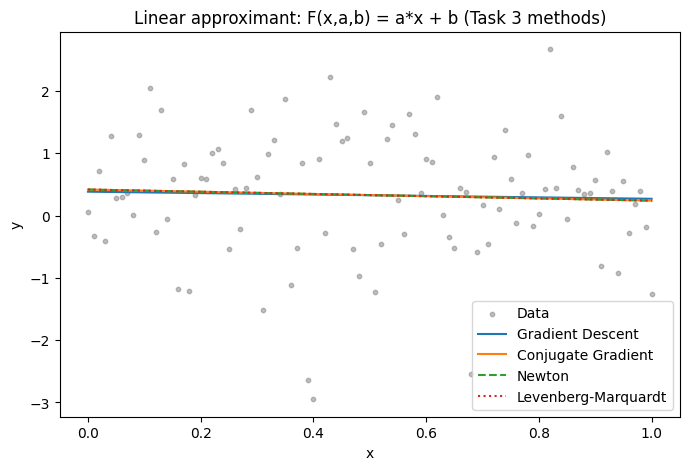

In [33]:
x_plot = [k/1000 for k in range(1001)]
plt.figure(figsize=(8, 5))
plt.scatter(xs, ys, s=10, color="gray", alpha=0.5, label="Data")

plt.plot(x_plot, [linear_approximant(x, a_gd, b_gd) for x in x_plot], label="Gradient Descent")
plt.plot(x_plot, [linear_approximant(x, a_cg, b_cg) for x in x_plot], label="Conjugate Gradient")
plt.plot(x_plot, [linear_approximant(x, a_nm, b_nm) for x in x_plot], label="Newton", linestyle="--")
plt.plot(x_plot, [linear_approximant(x, a_lm, b_lm) for x in x_plot], label="Levenberg-Marquardt", linestyle=":")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear approximant: F(x,a,b) = a*x + b (Task 3 methods)")
plt.legend()
plt.show()

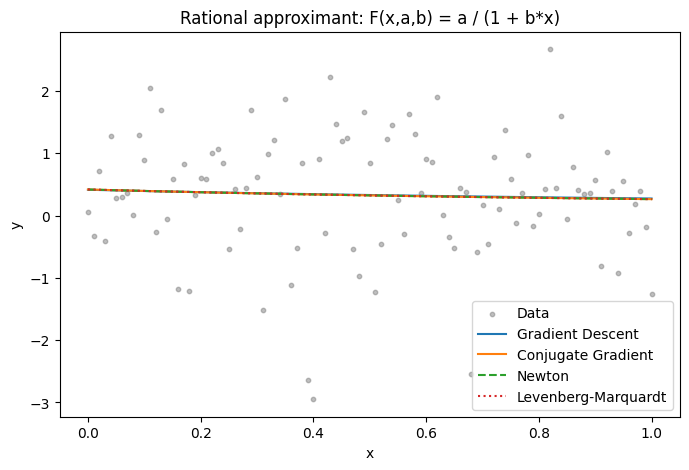

In [34]:
x_plot = [k/1000 for k in range(1001)]
plt.figure(figsize=(8, 5))
plt.scatter(xs, ys, s=10, color="gray", alpha=0.5, label="Data")

plt.plot(x_plot, [rational_approximant(x, a_gdr, b_gdr) for x in x_plot], label="Gradient Descent")
plt.plot(x_plot, [rational_approximant(x, a_cgr, b_cgr) for x in x_plot], label="Conjugate Gradient")
plt.plot(x_plot, [rational_approximant(x, a_nmr, b_nmr) for x in x_plot], label="Newton", linestyle="--")
plt.plot(x_plot, [rational_approximant(x, a_lmr, b_lmr) for x in x_plot], label="Levenberg-Marquardt", linestyle=":")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Rational approximant: F(x,a,b) = a / (1 + b*x)")
plt.legend()
plt.show()

# Practice 2 (for comparison)  

In [35]:
x3_fun = lambda x: x**3
abs_fun = lambda x: abs(x - 0.2)
sin_fun = lambda x: x * math.sin(1/x)

In [36]:
def exhaustive_search(f, a, b, eps):
  n = math.ceil((b - a) / eps)
  calcs_cnt = 0

  best_x = a
  best_f = f(a)
  calcs_cnt += 1

  for k in range(1, n + 1):
    x_k = a + k * (b - a) / n
    f_k = f(x_k)
    calcs_cnt += 1
    if f_k < best_f:
      best_f = f_k
      best_x = x_k

  iterations = n + 1
  return best_f, best_x, calcs_cnt, iterations

In [37]:
x3_best_f_es, x3_best_x_es, x3_calcs_cnt_es, x3_iterations_es = exhaustive_search(x3_fun, 0, 1,  0.001)
print(f"f(x) = 𝑥^3 : min(𝑥) = {x3_best_x_es:.3f}, min f(𝑥) = {x3_best_f_es:.3f}, calculations = {x3_calcs_cnt_es}, iterations = {x3_iterations_es}")

abs_best_f_es, abs_best_x_es, abs_calcs_cnt_es, abs_iterations_es = exhaustive_search(abs_fun, 0, 1,  0.001)
print(f"f(x) = |𝑥 − 0.2| : min(𝑥) = {abs_best_x_es:.3f}, min f(𝑥) = {abs_best_f_es:.3f}, calculations = {abs_calcs_cnt_es}, iterations = {abs_iterations_es}")

sin_best_f_es, sin_best_x_es, sin_calcs_cnt_es, sin_iterations_es = exhaustive_search(sin_fun, 0.01, 1,  0.001)
print(f"f(x) = 𝑥 * sin(1/x) : min(𝑥) = {sin_best_x_es:.3f}, min f(𝑥) = {sin_best_f_es:.3f}, calculations = {sin_calcs_cnt_es}, iterations = {sin_iterations_es}")

f(x) = 𝑥^3 : min(𝑥) = 0.000, min f(𝑥) = 0.000, calculations = 1001, iterations = 1001
f(x) = |𝑥 − 0.2| : min(𝑥) = 0.200, min f(𝑥) = 0.000, calculations = 1001, iterations = 1001
f(x) = 𝑥 * sin(1/x) : min(𝑥) = 0.223, min f(𝑥) = -0.217, calculations = 991, iterations = 991


In [38]:
def dichotomy(f, a, b, eps):
  calcs_cnt = 0
  iterations = 0

  while b - a >= eps:
    x1 = (a + b - (eps/2)) / 2
    x2 = (a + b + (eps/2)) / 2

    f_x1 = f(x1)
    f_x2 = f(x2)
    calcs_cnt += 2

    if f_x1 <= f_x2:
      b = x2
    else:
      a = x1

    iterations +=1

  best_x = (a + b) / 2
  best_f = f(best_x)
  calcs_cnt += 1
  return best_f, best_x, calcs_cnt, iterations

In [39]:
x3_best_f_d, x3_best_x_d, x3_calcs_cnt_d, x3_iterations_d = dichotomy(x3_fun, 0, 1,  0.001)
print(f"f(x) = 𝑥^3 : min(𝑥) = {x3_best_x_d:.3f}, min f(𝑥) = {x3_best_f_d:.3f}, calculations = {x3_calcs_cnt_d}, iterations = {x3_iterations_d}")

abs_best_f_d, abs_best_x_d, abs_calcs_cnt_d, abs_iterations_d = dichotomy(abs_fun, 0, 1,  0.001)
print(f"f(x) = |𝑥 − 0.2| : min(𝑥) = {abs_best_x_d:.3f}, min f(𝑥) = {abs_best_f_d:.3f}, calculations = {abs_calcs_cnt_d}, iterations = {abs_iterations_d}")

sin_best_f_d, sin_best_x_d, sin_calcs_cnt_d, sin_iterations_d = dichotomy(sin_fun, 0.01, 1,  0.001)
print(f"f(x) = 𝑥 * sin(1/x) : min(𝑥) = {sin_best_x_d:.3f}, min f(𝑥) = {sin_best_f_d:.3f}, calculations = {sin_calcs_cnt_d}, iterations = {sin_iterations_d}")

f(x) = 𝑥^3 : min(𝑥) = 0.000, min f(𝑥) = 0.000, calculations = 23, iterations = 11
f(x) = |𝑥 − 0.2| : min(𝑥) = 0.200, min f(𝑥) = 0.000, calculations = 23, iterations = 11
f(x) = 𝑥 * sin(1/x) : min(𝑥) = 0.223, min f(𝑥) = -0.217, calculations = 23, iterations = 11


In [40]:
x3_best_f_gs, x3_best_x_gs, x3_calcs_cnt_gs, x3_iterations_gs = golden_section(x3_fun, 0, 1,  0.001)
print(f"f(x) = 𝑥^3 : min(𝑥) = {x3_best_x_gs:.3f}, min f(𝑥) = {x3_best_f_gs:.3f}, calculations = {x3_calcs_cnt_gs}, iterations = {x3_iterations_gs}")

abs_best_f_gs, abs_best_x_gs, abs_calcs_cnt_gs, abs_iterations_gs = golden_section(abs_fun, 0, 1,  0.001)
print(f"f(x) = |𝑥 − 0.2| : min(𝑥) = {abs_best_x_gs:.3f}, min f(𝑥) = {abs_best_f_gs:.3f}, calculations = {abs_calcs_cnt_gs}, iterations = {abs_iterations_gs}")

sin_best_f_gs, sin_best_x_gs, sin_calcs_cnt_gs, sin_iterations_gs = golden_section(sin_fun, 0.01, 1,  0.001)
print(f"f(x) = 𝑥 * sin(1/x) : min(𝑥) = {sin_best_x_gs:.3f}, min f(𝑥) = {sin_best_f_gs:.3f}, calculations = {sin_calcs_cnt_gs}, iterations = {sin_iterations_gs}")

f(x) = 𝑥^3 : min(𝑥) = 0.000, min f(𝑥) = 0.000, calculations = 18, iterations = 15
f(x) = |𝑥 − 0.2| : min(𝑥) = 0.200, min f(𝑥) = 0.000, calculations = 18, iterations = 15
f(x) = 𝑥 * sin(1/x) : min(𝑥) = 0.223, min f(𝑥) = -0.217, calculations = 18, iterations = 15


In [41]:
results = pd.DataFrame([
    {"Function": "x^3",          "Method": "Exhaustive search", "x*": x3_best_x_es,  "f(x*)": x3_best_f_es,  "f-calculations": x3_calcs_cnt_es,  "Iterations": x3_iterations_es},
    {"Function": "x^3",          "Method": "Dichotomy",         "x*": x3_best_x_d,   "f(x*)": x3_best_f_d,   "f-calculations": x3_calcs_cnt_d,   "Iterations": x3_iterations_d},
    {"Function": "x^3",          "Method": "Golden section",    "x*": x3_best_x_gs,  "f(x*)": x3_best_f_gs,  "f-calculations": x3_calcs_cnt_gs,  "Iterations": x3_iterations_gs},

    {"Function": "|x-0.2|",      "Method": "Exhaustive search", "x*": abs_best_x_es, "f(x*)": abs_best_f_es, "f-calculations": abs_calcs_cnt_es, "Iterations": abs_iterations_es},
    {"Function": "|x-0.2|",      "Method": "Dichotomy",         "x*": abs_best_x_d,  "f(x*)": abs_best_f_d,  "f-calculations": abs_calcs_cnt_d,  "Iterations": abs_iterations_d},
    {"Function": "|x-0.2|",      "Method": "Golden section",    "x*": abs_best_x_gs, "f(x*)": abs_best_f_gs, "f-calculations": abs_calcs_cnt_gs, "Iterations": abs_iterations_gs},

    {"Function": "x*sin(1/x)",   "Method": "Exhaustive search", "x*": sin_best_x_es, "f(x*)": sin_best_f_es, "f-calculations": sin_calcs_cnt_es, "Iterations": sin_iterations_es},
    {"Function": "x*sin(1/x)",   "Method": "Dichotomy",         "x*": sin_best_x_d,  "f(x*)": sin_best_f_d,  "f-calculations": sin_calcs_cnt_d,  "Iterations": sin_iterations_d},
    {"Function": "x*sin(1/x)",   "Method": "Golden section",    "x*": sin_best_x_gs, "f(x*)": sin_best_f_gs, "f-calculations": sin_calcs_cnt_gs, "Iterations": sin_iterations_gs},
])

results

,Function,Method,x*,f(x*),f-calculations,Iterations
0,x^3,Exhaustive search,0.000000,0.000000e+00,1001,1001
1,x^3,Dichotomy,0.000494,1.205674e-10,23,11
2,x^3,Golden section,0.000367,4.925680e-11,18,15
3,|x-0.2|,Exhaustive search,0.200000,0.000000e+00,1001,1001
4,|x-0.2|,Dichotomy,0.200101,1.011963e-04,23,11
5,|x-0.2|,Golden section,0.200073,7.331374e-05,18,15
6,x*sin(1/x),Exhaustive search,0.223000,-2.172246e-01,991,991
7,x*sin(1/x),Dichotomy,0.222596,-2.172335e-01,23,11
8,x*sin(1/x),Golden section,0.222720,-2.172323e-01,18,15


In [42]:
def multidimensional_exhaustive(F, xs, ys, a_lo, a_hi, b_lo, b_hi, eps):
  n_a = math.ceil((a_hi - a_lo) / eps)
  n_b = math.ceil((b_hi - b_lo) / eps)
  calcs_cnt = 0

  best_a = a_lo
  best_b = b_lo
  best_d = D(F, a_lo, b_lo, xs, ys)
  calcs_cnt += 1

  for i in range(n_a + 1):
        a = a_lo + i * (a_hi - a_lo) / n_a
        for j in range(n_b + 1):
            b = b_lo + j * (b_hi - b_lo) / n_b
            d = D(F, a, b, xs, ys)
            calcs_cnt += 1
            if d < best_d:
                best_d = d
                best_a, best_b = a, b

  iterations = (n_a + 1) * (n_b + 1)
  return best_a, best_b, best_d, calcs_cnt, iterations

In [43]:
linear_a_me, linear_b_me, linear_d_me, linear_calcs_me, linear_iters_me = multidimensional_exhaustive(linear_approximant, xs, ys, 0, 1, 0, 1, 0.001)
print(f" Linear: a = {linear_a_me:.4f}, b = {linear_b_me:.4f}, D = {linear_d_me:.4f}, calcs = {linear_calcs_me}, iterations = {linear_iters_me}")

rational_a_me, rational_b_me, rational_d_me, rational_calcs_me, rational_iters_me = multidimensional_exhaustive(rational_approximant, xs, ys, 0, 1, 0, 1, 0.001)
print(f" Rational: a = {rational_a_me:.4f}, b = {rational_b_me:.4f}, D = {rational_d_me:.4f}, calcs = {rational_calcs_me}, iterations = {rational_iters_me}")

 Linear: a = 0.0000, b = 0.3280, D = 98.3720, calcs = 1002002, iterations = 1002001
 Rational: a = 0.4180, b = 0.5920, D = 98.1413, calcs = 1002002, iterations = 1002001


In [44]:
def minimize_a(F, b_fixed, xs, ys, a_lo, a_hi, eps):
    objective = lambda a: D(F, a, b_fixed, xs, ys)
    best_d, best_a, calcs, iters = golden_section(objective, a_lo, a_hi, eps)
    return best_a, best_d, calcs, iters

def minimize_b(F, a_fixed, xs, ys, b_lo, b_hi, eps):
    objective = lambda b: D(F, a_fixed, b, xs, ys)
    best_d, best_b, calcs, iters = golden_section(objective, b_lo, b_hi, eps)
    return best_b, best_d, calcs, iters

In [45]:
def gauss_method(F, xs, ys, a0, b0, a_lo, a_hi, b_lo, b_hi, eps):
  calcs_cnt = 0
  iterations = 0

  a,b = a0,b0

  while True:
    new_a, new_d, calcs_a, iters_a = minimize_a(F, b, xs, ys, a_lo, a_hi, eps)
    calcs_cnt += calcs_a

    new_b, new_d, calcs_b, iters_b = minimize_b(F, new_a, xs, ys, b_lo, b_hi, eps)
    calcs_cnt += calcs_b

    iterations += 1

    if abs(new_a - a) < eps and abs(new_b - b) < eps:
      a, b = new_a, new_b
      break

    a, b = new_a, new_b

  best_d = D(F, a, b, xs, ys)
  calcs_cnt += 1
  return a, b, best_d, calcs_cnt, iterations

In [46]:
linear_a_g, linear_b_g, linear_d_g, linear_calcs_g, linear_iters_g = gauss_method(linear_approximant, xs, ys, 0.5, 0.5, 0, 1, 0, 1, 0.001)
print(f" Linear: a = {linear_a_g:.4f}, b = {linear_b_g:.4f}, D = {linear_d_g:.4f}, calcs = {linear_calcs_g}, iterations = {linear_iters_g}")

rational_a_g, rational_b_g, rational_d_g, rational_calcs_g, rational_iters_g = gauss_method(rational_approximant, xs, ys, 0.5, 0.5, 0, 1, 0, 1, 0.001)
print(f" Rational: a = {rational_a_g:.4f}, b = {rational_b_g:.4f}, D = {rational_d_g:.4f}, calcs = {rational_calcs_g}, iterations = {rational_iters_g}")

 Linear: a = 0.0004, b = 0.3278, D = 98.3731, calcs = 73, iterations = 2
 Rational: a = 0.4175, b = 0.5897, D = 98.1413, calcs = 433, iterations = 12


In [47]:
def f_D(F, point, xs, ys):
    a, b = point
    return D(F, a, b, xs, ys)

In [48]:
def nelder_mead(F, xs, ys, x0, step, eps):
  calcs_cnt = 0
  iterations = 0

  x1 = [x0[0], x0[1]]
  x2 = [x0[0] + step, x0[1]]
  x3 = [x0[0], x0[1] + step]
  simplex = [x1, x2, x3]

  f_vals = [f_D(F, p, xs, ys) for p in simplex]
  calcs_cnt += 3

  while True:
    order = sorted(range(3), key=lambda i: f_vals[i])
    x_l, x_g, x_h = simplex[order[0]], simplex[order[1]], simplex[order[2]]
    f_l, f_g, f_h = f_vals[order[0]], f_vals[order[1]], f_vals[order[2]]
    iterations += 1

    if abs(f_h - f_l) < eps:
      break

    x_c = [(x_l[0] + x_g[0]) / 2, (x_l[1] + x_g[1]) / 2]
    x_r = [x_c[0] + (x_c[0] - x_h[0]), x_c[1] + (x_c[1] - x_h[1])]
    f_r = f_D(F, x_r, xs, ys)
    calcs_cnt += 1

    if f_r < f_l:
      x_e = [x_c[0] + 2 * (x_r[0] - x_c[0]), x_c[1] + 2 * (x_r[1] - x_c[1])]
      f_e = f_D(F, x_e, xs, ys)
      calcs_cnt += 1
      if f_e < f_r:
        new_point, new_f = x_e, f_e
      else:
        new_point, new_f = x_r, f_r
    elif f_r < f_g:
      new_point, new_f = x_r, f_r
    elif f_r < f_h:
      x_s = [0.5 * x_r[0] + 0.5 * x_c[0], 0.5 * x_r[1] + 0.5 * x_c[1]]
      f_s = f_D(F, x_s, xs, ys)
      calcs_cnt += 1
      if f_s < f_r:
        new_point, new_f = x_s, f_s
      else:
        x_g_new = [(x_g[0] + x_l[0]) / 2, (x_g[1] + x_l[1]) / 2]
        x_h_new = [(x_h[0] + x_l[0]) / 2, (x_h[1] + x_l[1]) / 2]
        f_g_new = f_D(F, x_g_new, xs, ys)
        f_h_new = f_D(F, x_h_new, xs, ys)
        calcs_cnt += 2
        simplex = [x_l, x_g_new, x_h_new]
        f_vals = [f_l, f_g_new, f_h_new]
        continue
    else:
      x_s = [0.5 * x_h[0] + 0.5 * x_c[0], 0.5 * x_h[1] + 0.5 * x_c[1]]
      f_s = f_D(F, x_s, xs, ys)
      calcs_cnt += 1
      if f_s < f_h:
        new_point, new_f = x_s, f_s
      else:
        x_g_new = [(x_g[0] + x_l[0]) / 2, (x_g[1] + x_l[1]) / 2]
        x_h_new = [(x_h[0] + x_l[0]) / 2, (x_h[1] + x_l[1]) / 2]
        f_g_new = f_D(F, x_g_new, xs, ys)
        f_h_new = f_D(F, x_h_new, xs, ys)
        calcs_cnt += 2
        simplex = [x_l, x_g_new, x_h_new]
        f_vals = [f_l, f_g_new, f_h_new]
        continue

    simplex = [x_l, x_g, new_point]
    f_vals = [f_l, f_g, new_f]

  best_idx = f_vals.index(min(f_vals))
  best_point = simplex[best_idx]
  best_d = f_vals[best_idx]
  return best_point[0], best_point[1], best_d, calcs_cnt, iterations

In [49]:
linear_a_nd, linear_b_nd, linear_d_nd, linear_calcs_nd, linear_iters_nd = nelder_mead(linear_approximant, xs, ys, [0.5, 0.5], 0.1, 0.001)
print(f" Linear: a = {linear_a_nd:.4f}, b = {linear_b_nd:.4f}, D = {linear_d_nd:.4f}, calcs = {linear_calcs_nd}, iterations = {linear_iters_nd}")

rational_a_nd, rational_b_nd, rational_d_nd, rational_calcs_nd, rational_iters_nd = nelder_mead(rational_approximant, xs, ys, [0.5, 0.5], 0.1, 0.001)
print(f" Rational: a = {rational_a_nd:.4f}, b = {rational_b_nd:.4f}, D = {rational_d_nd:.4f}, calcs = {rational_calcs_nd}, iterations = {rational_iters_nd}")

 Linear: a = -0.1819, b = 0.4174, D = 98.1026, calcs = 43, iterations = 22
 Rational: a = 0.4194, b = 0.5968, D = 98.1414, calcs = 21, iterations = 11


# Comparison

In [50]:
results_all = pd.DataFrame([
    {"Function": "Linear",   "Method": "Exhaustive search", "a": linear_a_me,    "b": linear_b_me,    "D(a,b)": linear_d_me,    "f-calculations": linear_calcs_me,    "Iterations": linear_iters_me},
    {"Function": "Linear",   "Method": "Gauss",              "a": linear_a_g,     "b": linear_b_g,     "D(a,b)": linear_d_g,     "f-calculations": linear_calcs_g,     "Iterations": linear_iters_g},
    {"Function": "Linear",   "Method": "Nelder-Mead",        "a": linear_a_nd,    "b": linear_b_nd,    "D(a,b)": linear_d_nd,    "f-calculations": linear_calcs_nd,    "Iterations": linear_iters_nd},
    {"Function": "Linear",   "Method": "Gradient Descent",   "a": a_gd,   "b": b_gd,   "D(a,b)": D(linear_approximant, a_gd, b_gd, xs, ys),     "f-calculations": calcs_cnt_dg,  "Iterations": iterations_gd},
    {"Function": "Linear",   "Method": "Conjugate Gradient", "a": a_cg,   "b": b_cg,   "D(a,b)": D(linear_approximant, a_cg, b_cg, xs, ys),     "f-calculations": calcs_cnt_cg,  "Iterations": iterations_cg},
    {"Function": "Linear",   "Method": "Newton",             "a": a_nm,   "b": b_nm,   "D(a,b)": D(linear_approximant, a_nm, b_nm, xs, ys),     "f-calculations": calcs_cnt_nm,  "Iterations": iterations_nm},
    {"Function": "Linear",   "Method": "Levenberg-Marquardt","a": a_lm,   "b": b_lm,   "D(a,b)": D(linear_approximant, a_lm, b_lm, xs, ys),     "f-calculations": calcs_cnt_lm,  "Iterations": iterations_lm},

    {"Function": "Rational", "Method": "Exhaustive search", "a": rational_a_me,  "b": rational_b_me,  "D(a,b)": rational_d_me,  "f-calculations": rational_calcs_me,  "Iterations": rational_iters_me},
    {"Function": "Rational", "Method": "Gauss",              "a": rational_a_g,   "b": rational_b_g,   "D(a,b)": rational_d_g,   "f-calculations": rational_calcs_g,   "Iterations": rational_iters_g},
    {"Function": "Rational", "Method": "Nelder-Mead",        "a": rational_a_nd,  "b": rational_b_nd,  "D(a,b)": rational_d_nd,  "f-calculations": rational_calcs_nd,  "Iterations": rational_iters_nd},
    {"Function": "Rational", "Method": "Gradient Descent",   "a": a_gdr,  "b": b_gdr,  "D(a,b)": D(rational_approximant, a_gdr, b_gdr, xs, ys), "f-calculations": calcs_cnt_gbr, "Iterations": iterations_gdr},
    {"Function": "Rational", "Method": "Conjugate Gradient", "a": a_cgr,  "b": b_cgr,  "D(a,b)": D(rational_approximant, a_cgr, b_cgr, xs, ys), "f-calculations": calcs_cnt_cgr, "Iterations": iterations_cgr},
    {"Function": "Rational", "Method": "Newton",             "a": a_nmr,  "b": b_nmr,  "D(a,b)": D(rational_approximant, a_nmr, b_nmr, xs, ys), "f-calculations": calcs_cnt_nmr, "Iterations": iterations_nmr},
    {"Function": "Rational", "Method": "Levenberg-Marquardt","a": a_lmr,  "b": b_lmr,  "D(a,b)": D(rational_approximant, a_lmr, b_lmr, xs, ys), "f-calculations": calcs_cnt_lmr, "Iterations": iterations_lmr},
])

results_all

,Function,Method,a,b,"D(a,b)",f-calculations,Iterations
0,Linear,Exhaustive search,0.000000,0.328000,98.371982,1002002,1002001
1,Linear,Gauss,0.000367,0.327791,98.373098,73,2
2,Linear,Nelder-Mead,-0.181902,0.417400,98.102564,43,22
3,Linear,Gradient Descent,-0.113708,0.382480,98.137389,15150,150
4,Linear,Conjugate Gradient,-0.178338,0.417235,98.102177,404,4
5,Linear,Newton,-0.177281,0.416551,98.102165,202,2
6,Linear,Levenberg-Marquardt,-0.177281,0.416551,98.102165,101,1
7,Rational,Exhaustive search,0.418000,0.592000,98.141319,1002002,1002001
8,Rational,Gauss,0.417508,0.589717,98.141319,433,12
9,Rational,Nelder-Mead,0.419434,0.596826,98.141387,21,11


When comparing all the methods, it is evident that most of them converged to a similar minimum—whether they were zero-, first-, or second-order methods. The Gauss method and exhaustive search stand out, however, as they yielded different results; this was because they were constrained by a search area that did not encompass the actual minimum. Overall, it can also be noted that methods utilizing derivatives and gradients prove to be more effective.

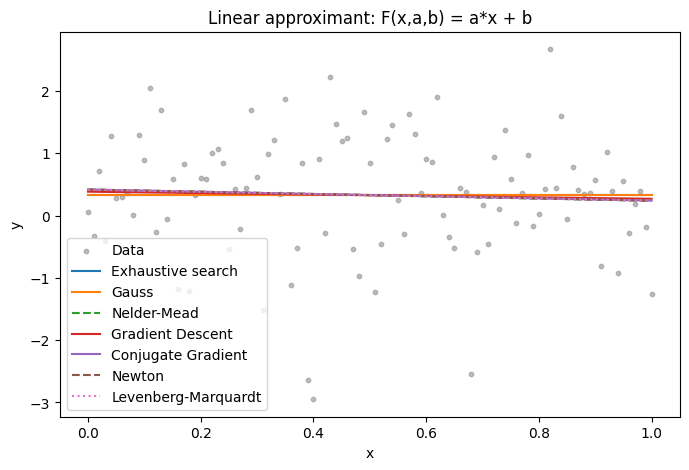

In [51]:
import matplotlib.pyplot as plt

x_plot = [k/1000 for k in range(1001)]
plt.figure(figsize=(8, 5))
plt.scatter(xs, ys, s=10, color="gray", alpha=0.5, label="Data")

plt.plot(x_plot, [linear_approximant(x, linear_a_me, linear_b_me) for x in x_plot], label="Exhaustive search")
plt.plot(x_plot, [linear_approximant(x, linear_a_g, linear_b_g) for x in x_plot], label="Gauss")
plt.plot(x_plot, [linear_approximant(x, linear_a_nd, linear_b_nd) for x in x_plot], label="Nelder-Mead", linestyle="--")

plt.plot(x_plot, [linear_approximant(x, a_gd, b_gd) for x in x_plot], label="Gradient Descent")
plt.plot(x_plot, [linear_approximant(x, a_cg, b_cg) for x in x_plot], label="Conjugate Gradient")
plt.plot(x_plot, [linear_approximant(x, a_nm, b_nm) for x in x_plot], label="Newton", linestyle="--")
plt.plot(x_plot, [linear_approximant(x, a_lm, b_lm) for x in x_plot], label="Levenberg-Marquardt", linestyle=":")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear approximant: F(x,a,b) = a*x + b")
plt.legend()
plt.show()


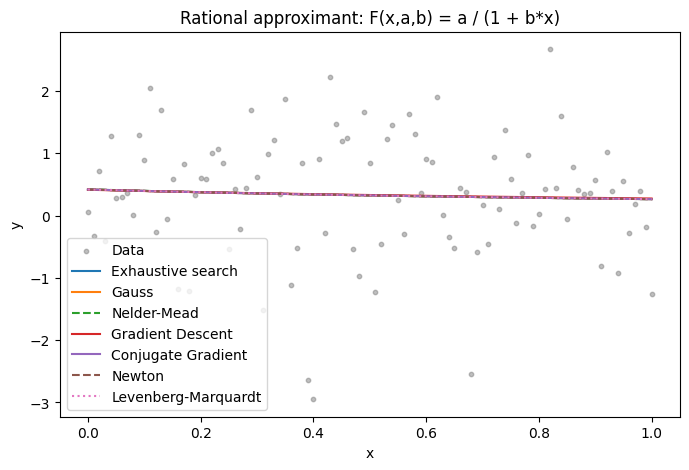

In [52]:
plt.figure(figsize=(8, 5))
plt.scatter(xs, ys, s=10, color="gray", alpha=0.5, label="Data")

plt.plot(x_plot, [rational_approximant(x, rational_a_me, rational_b_me) for x in x_plot], label="Exhaustive search")
plt.plot(x_plot, [rational_approximant(x, rational_a_g, rational_b_g) for x in x_plot], label="Gauss")
plt.plot(x_plot, [rational_approximant(x, rational_a_nd, rational_b_nd) for x in x_plot], label="Nelder-Mead", linestyle="--")

plt.plot(x_plot, [rational_approximant(x, a_gdr, b_gdr) for x in x_plot], label="Gradient Descent")
plt.plot(x_plot, [rational_approximant(x, a_cgr, b_cgr) for x in x_plot], label="Conjugate Gradient")
plt.plot(x_plot, [rational_approximant(x, a_nmr, b_nmr) for x in x_plot], label="Newton", linestyle="--")
plt.plot(x_plot, [rational_approximant(x, a_lmr, b_lmr) for x in x_plot], label="Levenberg-Marquardt", linestyle=":")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Rational approximant: F(x,a,b) = a / (1 + b*x)")
plt.legend()
plt.show()